# Note 03 Deep Dive: Vector Spaces & Subspaces (Applied Math for DS & AI)

Companion notebook for [`03-Vector-Spaces-and-Subspaces.md`](../03-Vector-Spaces-and-Subspaces.md). The shared notebook `linear_algebra_part1.ipynb` (Part D) covers the class examples; this one goes further.

| Part | Topic |
|---|---|
| 1 | A randomised subspace checker that **finds closure counterexamples automatically** |
| 2 | Symbolic (sympy) proofs of closure for general vectors, matrices and polynomials |
| 3 | The axioms of P₂ checked symbolically, and the consequences 0·v = 0, (−1)v = −v |
| 4 | Intersection, union and sum of subspaces |
| 5 | Null space and column space are subspaces; Ax = b gives an affine set |
| 6 | 3-D picture: plane through the origin vs an affine plane |
| 7 | Word-embedding arithmetic with hand-made vectors |
| 8 | Images as vectors: blending, and PCA finding a low-dimensional subspace (sklearn digits) |
| 9 | Audio as vectors: mixing signals, superposition, band-limited signals |
| 10 | Checks for the remaining worked-example and practice-problem numbers |

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.linalg import null_space
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## Part 1 — A randomised subspace checker

A set is described by a **membership test** `member(v) -> bool` and a **sampler** that draws random elements of the set. The checker tries many random pairs `u, v` and scalars `k` and reports the first vector that escapes. Random testing can **disprove** closure (one counterexample is a proof) but can only *suggest* closure; Part 2 does the proofs.

In [2]:
def check_subspace(name, member, sample, dim_shape, trials=2000, tol=1e-9):
    zero = np.zeros(dim_shape)
    if not member(zero):
        print(f"{name:42s} NOT a subspace: zero vector missing")
        return False
    for _ in range(trials):
        u, v = sample(), sample()
        k = rng.choice([-1.0, 0.0, 2.0, -3.5, rng.normal() * 5])
        if not member(u + v):
            print(f"{name:42s} NOT a subspace: u+v escapes\n    u={u.ravel()}, v={v.ravel()}, u+v={(u+v).ravel()}")
            return False
        if not member(k * u):
            print(f"{name:42s} NOT a subspace: k*u escapes\n    k={k}, u={u.ravel()}, k*u={(k*u).ravel()}")
            return False
    print(f"{name:42s} passed {trials} random closure tests (consistent with a subspace)")
    return True

r = lambda: rng.normal()
tests = [
    ("W1  {(x,y): x = 3y}",            lambda v: abs(v[0] - 3*v[1]) < 1e-9,   lambda: (lambda t: np.array([3*t, t]))(r()), (2,)),
    ("W2  {(x,y): y = x^2}",           lambda v: abs(v[1] - v[0]**2) < 1e-9,  lambda: (lambda t: np.array([t, t*t]))(r()), (2,)),
    ("W3  {x-2y+z=0 and y+z=0}",       lambda v: abs(v[0]-2*v[1]+v[2]) < 1e-9 and abs(v[1]+v[2]) < 1e-9,
                                       lambda: r() * np.array([-3., -1., 1.]), (3,)),
    ("W4  {x+y+z=1}",                  lambda v: abs(v.sum() - 1) < 1e-9,      lambda: (lambda a, b: np.array([a, b, 1-a-b]))(r(), r()), (3,)),
    ("W5  {z >= 0} (upper half-space)", lambda v: v[2] >= 0,                    lambda: np.array([r(), r(), abs(r())]), (3,)),
    ("P13 {x^2 = y^2}",                lambda v: abs(v[0]**2 - v[1]**2) < 1e-9, lambda: (lambda t, s: np.array([t, s*t]))(r(), rng.choice([-1, 1])), (2,)),
    ("P3  first quadrant",             lambda v: v[0] >= 0 and v[1] >= 0,     lambda: np.abs(rng.normal(size=2)), (2,)),
]
for t in tests:
    check_subspace(*t)

W1  {(x,y): x = 3y}                        passed 2000 random closure tests (consistent with a subspace)
W2  {(x,y): y = x^2}                       NOT a subspace: u+v escapes
    u=[-1.7765  3.1559], v=[-0.2922  0.0854], u+v=[-2.0687  3.2413]
W3  {x-2y+z=0 and y+z=0}                   passed 2000 random closure tests (consistent with a subspace)
W4  {x+y+z=1}                              NOT a subspace: zero vector missing
W5  {z >= 0} (upper half-space)            NOT a subspace: k*u escapes
    k=-3.5, u=[1.1196 0.2989 0.5407], k*u=[-3.9185 -1.0461 -1.8923]
P13 {x^2 = y^2}                            NOT a subspace: u+v escapes
    u=[-1.3044  1.3044], v=[-1.9309 -1.9309], u+v=[-3.2353 -0.6265]
P3  first quadrant                         NOT a subspace: k*u escapes
    k=-3.5, u=[1.4541 0.6974], k*u=[-5.0895 -2.4409]


Now matrix sets (each "vector" is a 2×2 array).

In [3]:
sym = lambda: (lambda M: M + M.T)(rng.normal(size=(2, 2)))
inv = lambda: rng.normal(size=(2, 2))            # a random matrix is invertible with probability 1
trace0 = lambda: (lambda M: M - np.trace(M) / 2 * np.eye(2))(rng.normal(size=(2, 2)))
rank_le1 = lambda: np.outer(rng.normal(size=2), rng.normal(size=2))
idem = lambda: (lambda u: np.outer(u, u) / (u @ u))(rng.normal(size=2))  # projections P^2 = P

mat_tests = [
    ("W6  symmetric 2x2",             lambda A: np.allclose(A, A.T), sym, (2, 2)),
    ("W7  invertible 2x2",            lambda A: abs(np.linalg.det(A)) > 1e-12, inv, (2, 2)),
    ("W8  trace-zero 2x2",            lambda A: abs(np.trace(A)) < 1e-9, trace0, (2, 2)),
    ("P5  det = 0 (rank <= 1) 2x2",    lambda A: abs(np.linalg.det(A)) < 1e-9, rank_le1, (2, 2)),
    ("P15 idempotent A^2 = A",         lambda A: np.allclose(A @ A, A), idem, (2, 2)),
]
for t in mat_tests:
    check_subspace(*t)

W6  symmetric 2x2                          passed 2000 random closure tests (consistent with a subspace)
W7  invertible 2x2                         NOT a subspace: zero vector missing


W8  trace-zero 2x2                         passed 2000 random closure tests (consistent with a subspace)
P5  det = 0 (rank <= 1) 2x2                NOT a subspace: u+v escapes
    u=[-0.6376 -0.2165 -0.0042 -0.0014], v=[ 0.0413 -0.0064  0.1559 -0.0242], u+v=[-0.5963 -0.2229  0.1517 -0.0257]
P15 idempotent A^2 = A                     NOT a subspace: u+v escapes
    u=[0.0512 0.2203 0.2203 0.9488], v=[ 0.7902 -0.4072 -0.4072  0.2098], u+v=[ 0.8413 -0.1869 -0.1869  1.1587]


**Reading the output.** The invertible matrices fail at the very first check: the zero matrix has determinant 0. The determinant-zero set contains the zero matrix and is closed under scaling (det(kA) = k²det A = 0) but **not** under addition: two rank-1 matrices can add up to an invertible one.

## Part 2 — Symbolic proofs with sympy

A random test is evidence; a symbolic test with **general** entries is a proof. We write a general member using free parameters, form `u + v` and `k*u`, and check that the defining condition simplifies to 0.

In [4]:
a1, a2, b1, b2, c1, c2, k = sp.symbols('a1 a2 b1 b2 c1 c2 k', real=True)

# W1: x = 3y. General member (3s, s).
s1, s2 = sp.symbols('s1 s2', real=True)
u, v = sp.Matrix([3*s1, s1]), sp.Matrix([3*s2, s2])
cond = lambda w: sp.simplify(w[0] - 3*w[1])
print("W1  u+v:", cond(u + v), "  k*u:", cond(k*u))

# P2: plane x+y+z=0. General member (a, b, -a-b).
u, v = sp.Matrix([a1, b1, -a1-b1]), sp.Matrix([a2, b2, -a2-b2])
cond = lambda w: sp.simplify(w[0] + w[1] + w[2])
print("P2  u+v:", cond(u + v), "  k*u:", cond(k*u))

# W4: plane x+y+z=1. General member (a, b, 1-a-b).
u, v = sp.Matrix([a1, b1, 1-a1-b1]), sp.Matrix([a2, b2, 1-a2-b2])
cond = lambda w: sp.simplify(w[0] + w[1] + w[2] - 1)
print("W4  u+v gives (sum - 1) =", cond(u + v), "  k*u gives", sp.factor(cond(k*u)), " -> fails unless k = 1")

W1  u+v: 0   k*u: 0
P2  u+v: 0   k*u: 0
W4  u+v gives (sum - 1) = 1   k*u gives k - 1  -> fails unless k = 1


In [5]:
# W6: symmetric matrices; W8: trace-zero matrices
A = sp.Matrix([[a1, b1], [b1, c1]]); B = sp.Matrix([[a2, b2], [b2, c2]])
print("symmetric: (A+B)^T-(A+B) =", list((A+B).T - (A+B)), "  (kA)^T-kA =", list((k*A).T - k*A))
A = sp.Matrix([[a1, b1], [c1, -a1]]); B = sp.Matrix([[a2, b2], [c2, -a2]])
print("trace-zero: tr(A+B) =", (A+B).trace(), "  tr(kA) =", (k*A).trace())

# W7: invertible matrices. The symbolic det shows why closure fails
A = sp.Matrix([[a1, b1], [c1, c2]])
print("det(kA) =", sp.factor((k*A).det()), "  -> k = 0 gives det 0, so 0*A is not invertible")
print("I + (-I) =", list(sp.eye(2) + (-sp.eye(2))), " det =", (sp.eye(2) - sp.eye(2)).det())

symmetric: (A+B)^T-(A+B) = [0, 0, 0, 0]   (kA)^T-kA = [0, 0, 0, 0]
trace-zero: tr(A+B) = 0   tr(kA) = 0
det(kA) = k**2*(a1*c2 - b1*c1)   -> k = 0 gives det 0, so 0*A is not invertible
I + (-I) = [0, 0, 0, 0]  det = 0


In [6]:
# Polynomials in P2 as expressions in x
x = sp.symbols('x')
p = a1 + b1*x + c1*x**2
q = a2 + b2*x + c2*x**2

# W9a: {p in P2 : p(1) = 0}  (impose the condition by solving for the constant term)
p1 = p.subs(a1, -b1 - c1); q1 = q.subs(a2, -b2 - c2)
print("p(1)=0 set:  (p+q)(1) =", sp.simplify((p1 + q1).subs(x, 1)), "  (k p)(1) =", sp.simplify((k*p1).subs(x, 1)))

# W9b: {p : p(0) = 1} fails
p0 = p.subs(a1, 1); q0 = q.subs(a2, 1)
print("p(0)=1 set:  (p+q)(0) =", (p0 + q0).subs(x, 0), " (should be 1)")

# W9c: degree exactly 2 fails
print("deg-2 set:  (x^2 + x) + (-x^2) =", sp.expand((x**2 + x) + (-x**2)), "-> degree", sp.degree(x, x))

# P17: {p in P2 : p(2) = p(-1)}
print("p(2) - p(-1) =", sp.expand(p.subs(x, 2) - p.subs(x, -1)), " -> condition is b + c = 0 (linear, so a subspace)")

p(1)=0 set:  (p+q)(1) = 0   (k p)(1) = 0
p(0)=1 set:  (p+q)(0) = 2  (should be 1)
deg-2 set:  (x^2 + x) + (-x^2) = x -> degree 1
p(2) - p(-1) = 3*b1 + 3*c1  -> condition is b + c = 0 (linear, so a subspace)


In [7]:
# W10: functions. Solutions of y'' + y = 0 and y'' - 3y' + 2y = 0 are closed under + and scaling
t = sp.symbols('t'); C1, C2 = sp.symbols('C1 C2')
L1 = lambda y: sp.simplify(sp.diff(y, t, 2) + y)
print("y''+y for C1 sin t + C2 cos t :", L1(C1*sp.sin(t) + C2*sp.cos(t)))
L2 = lambda y: sp.simplify(sp.diff(y, t, 2) - 3*sp.diff(y, t) + 2*y)
for y in [sp.exp(t), sp.exp(2*t), 3*sp.exp(t) - 5*sp.exp(2*t)]:
    print(f"L2[{y}] =", L2(y))
f = sp.Function('f')
print("non-homogeneous y''-3y'+2y = 4:", sp.dsolve(sp.diff(f(t), t, 2) - 3*sp.diff(f(t), t) + 2*f(t) - 4))

y''+y for C1 sin t + C2 cos t : 0
L2[exp(t)] = 0
L2[exp(2*t)] = 0
L2[-5*exp(2*t) + 3*exp(t)] = 0


non-homogeneous y''-3y'+2y = 4: Eq(f(t), C1*exp(t) + C2*exp(2*t) + 2)


## Part 3 — The axioms of P₂, checked symbolically

P₂ = polynomials of degree ≤ 2. We verify all 10 axioms for **general** p, q, r and scalars a, b. Each line prints `True` when the two sides are identical polynomials.

In [8]:
a, b = sp.symbols('a b', real=True)
d0, d1, d2 = sp.symbols('d0 d1 d2', real=True)
r = d0 + d1*x + d2*x**2
zero = sp.Integer(0)
eq = lambda L, R: sp.expand(L - R) == 0
in_P2 = lambda e: sp.Poly(sp.expand(e), x).degree() <= 2
axioms = {
    "1 closure (+)":            in_P2(p + q),
    "2 p+q = q+p":              eq(p + q, q + p),
    "3 (p+q)+r = p+(q+r)":      eq((p + q) + r, p + (q + r)),
    "4 p + 0 = p":              eq(p + zero, p),
    "5 p + (-p) = 0":           eq(p + (-p), zero),
    "6 closure (.)":            in_P2(a*p),
    "7 a(p+q) = ap+aq":         eq(a*(p + q), a*p + a*q),
    "8 (a+b)p = ap+bp":         eq((a + b)*p, a*p + b*p),
    "9 a(bp) = (ab)p":          eq(a*(b*p), (a*b)*p),
    "10 1p = p":                eq(1*p, p),
}
for name, ok in axioms.items():
    print(f"{name:26s} {ok}")

1 closure (+)              True
2 p+q = q+p                True
3 (p+q)+r = p+(q+r)        True
4 p + 0 = p                True
5 p + (-p) = 0             True
6 closure (.)              True
7 a(p+q) = ap+aq           True
8 (a+b)p = ap+bp           True
9 a(bp) = (ab)p            True
10 1p = p                  True


In [9]:
# A concrete instance used in the note: p = 1 + 2x - x^2, q = 3 - x + 4x^2
P, Q = 1 + 2*x - x**2, 3 - x + 4*x**2
print("p + q      =", sp.expand(P + Q))
print("2(p + q)   =", sp.expand(2*(P + Q)), "  2p + 2q =", sp.expand(2*P + 2*Q))
print("(2 - 3)p   =", sp.expand((2 - 3)*P), "  2p - 3p =", sp.expand(2*P - 3*P))
print("0 * p      =", 0*P, "   (-1)*p + p =", sp.expand(-1*P + P))

p + q      = 3*x**2 + x + 4
2(p + q)   = 6*x**2 + 2*x + 8   2p + 2q = 6*x**2 + 2*x + 8
(2 - 3)p   = x**2 - 2*x - 1   2p - 3p = x**2 - 2*x - 1
0 * p      = 0    (-1)*p + p = 0


**Consequences of the axioms.** For coordinate spaces the identities 0·v = 0, k·0 = 0 and (−1)v = −v are obvious component by component; the note proves them from the axioms alone so they hold in *every* vector space (matrices, polynomials, functions).

In [10]:
v = rng.normal(size=4)
print("0*v      =", 0 * v)
print("(-1)*v + v =", (-1) * v + v)
M = rng.normal(size=(2, 3))
print("0*M =\n", 0 * M)
g = sp.sin(t) + t**3
print("(-1)*g + g =", sp.simplify(-1*g + g))

0*v      = [-0.  0.  0.  0.]
(-1)*v + v = [0. 0. 0. 0.]
0*M =
 [[-0. -0. -0.]
 [-0. -0. -0.]]
(-1)*g + g = 0


## Part 4 — Intersection, union and sum of subspaces

In [11]:
# U: y = x, W: y = -x in R^2
U = np.array([[1.0], [1.0]]); W = np.array([[1.0], [-1.0]])
# Intersection: solve s*(1,1) = t*(1,-1)  <=>  [U | -W] (s,t)^T = 0
print("null space of [U | -W]:", null_space(np.hstack([U, -W])).ravel(), " (empty => U ∩ W = {0})")

# Union: (1,1) in U and (1,-1) in W, but the sum?
s = np.array([1, 1]) + np.array([1, -1])
on_U = np.isclose(s[0], s[1]); on_W = np.isclose(s[0], -s[1])
print("(1,1)+(1,-1) =", s, " on U?", on_U, " on W?", on_W)

# Sum U + W = R^2: write (3,5) as u + w with u on the x-axis and w on y = x  (practice P21)
Ux = np.array([1.0, 0.0]); Wd = np.array([1.0, 1.0])
coef = np.linalg.solve(np.column_stack([Ux, Wd]), np.array([3.0, 5.0]))
print("coefficients:", coef, " u =", coef[0] * Ux, " w =", coef[1] * Wd)

null space of [U | -W]: []  (empty => U ∩ W = {0})
(1,1)+(1,-1) = [2 0]  on U? False  on W? False
coefficients: [-2.  5.]  u = [-2. -0.]  w = [5. 5.]


In [12]:
# Planes in R^3: P1 = {x - y - 2z = 0}, P2 = {x + y + z = 0}. Intersection is a line (practice P12)
N = sp.Matrix([[1, -1, -2], [1, 1, 1]])
print("direction of P1 ∩ P2:", list(N.nullspace()[0].T), " -> scaled:", list(2 * N.nullspace()[0].T))

direction of P1 ∩ P2: [1/2, -3/2, 1]  -> scaled: [1, -3, 2]


## Part 5 — Null space and column space are subspaces; Ax = b is affine

In [13]:
A = np.array([[1., 2, 3], [2, 4, 6]])           # rank 1, so N(A) is a plane in R^3
Nb = null_space(A)
print("basis of N(A) (columns):\n", Nb)
x1, x2 = Nb @ rng.normal(size=2), Nb @ rng.normal(size=2)
print("A(x1 + x2) =", A @ (x1 + x2), "   A(-7 x1) =", A @ (-7 * x1))

b = np.array([6., 12.])
xp = np.array([1., 1., 1.])                        # a particular solution: 1+2+3 = 6
print("A xp =", A @ xp)
xs = xp + Nb @ np.array([2.0, -1.0])              # another solution
print("A (xp + n) =", A @ xs, "  but A(xp + xs) =", A @ (xp + xs), " != b, so the solution set is not closed")

basis of N(A) (columns):
 [[ 0.9636 -0.    ]
 [-0.1482 -0.8321]
 [-0.2224  0.5547]]
A(x1 + x2) = [0. 0.]    A(-7 x1) = [0. 0.]
A xp = [ 6. 12.]
A (xp + n) = [ 6. 12.]   but A(xp + xs) = [12. 24.]  != b, so the solution set is not closed


In [14]:
# Column space membership (practice P23)
A = sp.Matrix([[1, 2], [2, 4], [0, 1]])
for bvec in ([3, 6, 1], [1, 3, 0]):
    sol = sp.linsolve((A, sp.Matrix(bvec)))
    print(f"b = {bvec}:  solutions {sol}  ->  b in C(A)? {sol != sp.EmptySet}")

b = [3, 6, 1]:  solutions {(1, 1)}  ->  b in C(A)? True
b = [1, 3, 0]:  solutions EmptySet  ->  b in C(A)? False


## Part 6 — Plane through the origin vs an affine plane

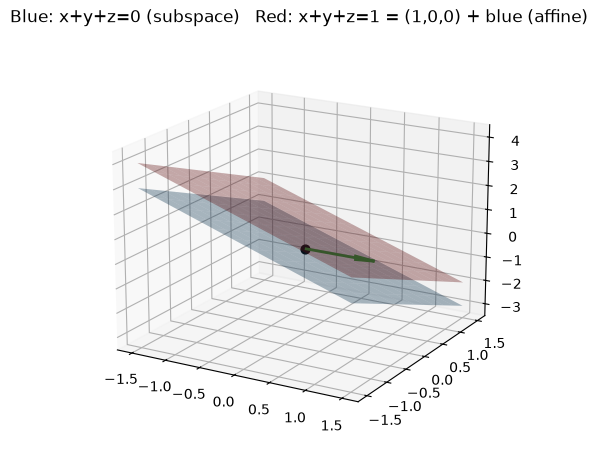

lambda= 0.3: sum of lam*p + (1-lam)*q = 1.0
lambda= 2.5: sum of lam*p + (1-lam)*q = 1.0
lambda=-1.0: sum of lam*p + (1-lam)*q = 1.0
p + q sums to 2.0    2p sums to 2.0


In [15]:
fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection='3d')
s_ = np.linspace(-1.5, 1.5, 12); X, Y = np.meshgrid(s_, s_)
ax.plot_surface(X, Y, -X - Y, alpha=0.35, color='tab:blue')
ax.plot_surface(X, Y, 1 - X - Y, alpha=0.35, color='tab:red')
ax.scatter([0], [0], [0], color='k', s=40)
ax.quiver(0, 0, 0, 1, 0, 0, color='tab:green', lw=2)
ax.set_title('Blue: x+y+z=0 (subspace)   Red: x+y+z=1 = (1,0,0) + blue (affine)')
ax.view_init(elev=18, azim=-60); plt.show()

# numeric check: the affine plane is closed under AFFINE combinations but not under + or scaling
p_, q_ = np.array([1., 0, 0]), np.array([0., 2, -1])     # both satisfy x+y+z = 1
for lam in (0.3, 2.5, -1.0):
    print(f"lambda={lam:4}: sum of lam*p + (1-lam)*q =", (lam * p_ + (1 - lam) * q_).sum())
print("p + q sums to", (p_ + q_).sum(), "   2p sums to", (2 * p_).sum())

## Part 7 — Word-embedding arithmetic with hand-made vectors

Real word2vec vectors have 300 learned dimensions with no names. To see the mechanism, we hand-build 4-dimensional vectors with interpretable axes: **(royalty, gender: +male/−female, adulthood, food)**.

In [16]:
E = {
    "king":     [0.95,  0.90, 0.70, 0.05],
    "queen":    [0.93, -0.88, 0.72, 0.04],
    "man":      [0.10,  0.85, 0.65, 0.02],
    "woman":    [0.08, -0.90, 0.66, 0.03],
    "prince":   [0.90,  0.86, 0.20, 0.02],
    "princess": [0.88, -0.87, 0.22, 0.03],
    "boy":      [0.05,  0.80, 0.10, 0.04],
    "girl":     [0.04, -0.82, 0.12, 0.05],
    "apple":    [0.02,  0.01, 0.30, 0.95],
}
E = {w: np.array(v) for w, v in E.items()}
cos = lambda a, b: a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

def analogy(a, b, c, k=3):
    v = E[a] - E[b] + E[c]                      # vector addition + scalar multiplication by -1
    ranked = sorted(((cos(v, E[w]), w) for w in E if w not in (a, b, c)), reverse=True)
    print(f"{a} - {b} + {c} = {v.round(2)}  ->", [(w, round(s, 4)) for s, w in ranked[:k]])

analogy("king", "man", "woman")
analogy("prince", "boy", "girl")
analogy("queen", "woman", "man")
print("man - woman  =", (E["man"] - E["woman"]).round(2))
print("king - queen =", (E["king"] - E["queen"]).round(2), " <- nearly the same 'gender direction'")

king - man + woman = [ 0.93 -0.85  0.71  0.06]  -> [('queen', np.float64(0.9998)), ('princess', np.float64(0.9429)), ('girl', np.float64(0.6836))]
prince - boy + girl = [ 0.89 -0.76  0.22  0.03]  -> [('princess', np.float64(0.9974)), ('queen', np.float64(0.9461)), ('woman', np.float64(0.676))]
queen - woman + man = [0.95 0.87 0.71 0.03]  -> [('king', np.float64(0.9997)), ('prince', np.float64(0.9411)), ('boy', np.float64(0.6856))]
man - woman  = [ 0.02  1.75 -0.01 -0.01]
king - queen = [ 0.02  1.78 -0.02  0.01]  <- nearly the same 'gender direction'


In [17]:
# Removing a direction = projecting onto a subspace (the idea behind embedding 'debiasing')
g = E["man"] - E["woman"]; g = g / np.linalg.norm(g)
proj_out = lambda v: v - (v @ g) * g              # lands in the subspace orthogonal to g
for w in ["king", "queen"]:
    print(f"{w:6s} after removing gender:", proj_out(E[w]).round(3))
print("cos(king, queen) before:", round(cos(E['king'], E['queen']), 4),
      "  after:", round(cos(proj_out(E['king']), proj_out(E['queen'])), 4))

king   after removing gender: [ 0.94  -0.006  0.705  0.055]
queen  after removing gender: [ 0.94  -0.006  0.715  0.035]
cos(king, queen) before: 0.2738   after: 0.9998


## Part 8 — Images as vectors (sklearn digits, 8×8 = 64 pixels)

data matrix: (1797, 64)  -> each image is a vector in R^64


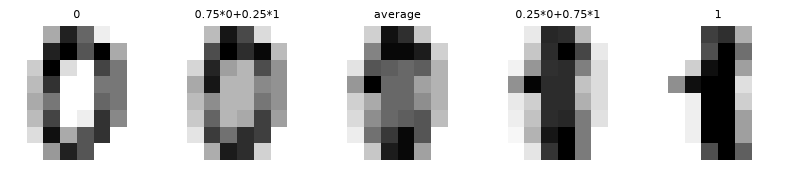

pixel range: 0.0 to 16.0  -> 3*image exceeds 16, so 'valid images' are a box, not a subspace


In [18]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
D = load_digits(); Xd = D.data
print("data matrix:", Xd.shape, " -> each image is a vector in R^64")
a_img, b_img = Xd[0], Xd[1]                         # a '0' and a '1'
fig, axs = plt.subplots(1, 5, figsize=(10, 2.2))
for ax, (lam, title) in zip(axs, [(1, '0'), (0.75, '0.75*0+0.25*1'), (0.5, 'average'), (0.25, '0.25*0+0.75*1'), (0, '1')]):
    ax.imshow((lam * a_img + (1 - lam) * b_img).reshape(8, 8), cmap='gray_r'); ax.set_title(title, fontsize=8); ax.axis('off')
plt.show()
print("pixel range:", Xd.min(), "to", Xd.max(), " -> 3*image exceeds 16, so 'valid images' are a box, not a subspace")

50% of variance needs  5 of 64 dimensions
80% of variance needs 13 of 64 dimensions
90% of variance needs 21 of 64 dimensions
95% of variance needs 29 of 64 dimensions
99% of variance needs 41 of 64 dimensions
first 2 components: 0.285   first 10: 0.738


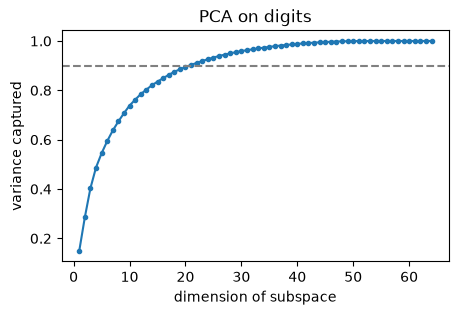

In [19]:
pca = PCA().fit(Xd)
cum = np.cumsum(pca.explained_variance_ratio_)
for th in (0.5, 0.8, 0.9, 0.95, 0.99):
    print(f"{int(th*100)}% of variance needs {np.searchsorted(cum, th) + 1:2d} of 64 dimensions")
print("first 2 components:", cum[1].round(3), "  first 10:", cum[9].round(3))
plt.figure(figsize=(5, 3)); plt.plot(np.arange(1, 65), cum, marker='.'); plt.axhline(0.9, ls='--', c='gray')
plt.xlabel('dimension of subspace'); plt.ylabel('variance captured'); plt.title('PCA on digits'); plt.show()

## Part 9 — Audio as vectors: mixing and superposition

each 20 ms clip is a vector of length 160
peaks of the mix (Hz): [450. 650.]
noise cancellation: max |(s1 + noise) + (-1)*noise - s1| = 1.1102230246251565e-16


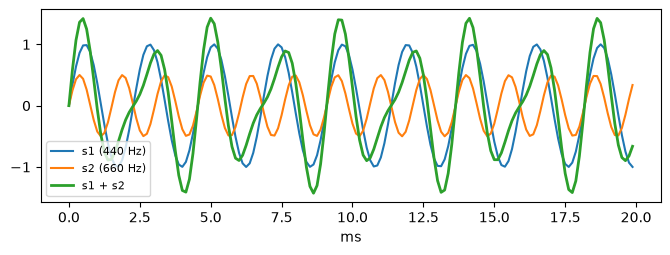

In [20]:
fs = 8000                                   # samples per second (telephone quality)
tt = np.arange(0, 0.02, 1 / fs)             # 20 ms -> a vector in R^160
s1 = np.sin(2 * np.pi * 440 * tt)           # A4
s2 = 0.5 * np.sin(2 * np.pi * 660 * tt)     # E5, quieter
mix = s1 + s2                               # mixing = vector addition
print("each 20 ms clip is a vector of length", tt.size)

# band-limited signals form a subspace: frequencies of the sum lie inside the union of the parts' bands
spec = lambda s: np.abs(np.fft.rfft(s))
freqs = np.fft.rfftfreq(tt.size, 1 / fs)
print("peaks of the mix (Hz):", freqs[spec(mix) > 0.25 * spec(mix).max()])
noise = 0.3 * rng.normal(size=tt.size)
print("noise cancellation: max |(s1 + noise) + (-1)*noise - s1| =", np.abs((s1 + noise) + (-1) * noise - s1).max())

plt.figure(figsize=(8, 2.5))
plt.plot(tt * 1000, s1, label='s1 (440 Hz)'); plt.plot(tt * 1000, s2, label='s2 (660 Hz)'); plt.plot(tt * 1000, mix, label='s1 + s2', lw=2)
plt.xlabel('ms'); plt.legend(fontsize=8); plt.show()

## Part 10 — Checks for the worked examples and practice problems

Every number quoted in Sections 3, 4, 7 and 15 of the note that is not produced by Parts 1–9 is recomputed here (labels match the note: W = worked example, P = practice problem).

In [21]:
x, t = sp.symbols('x t')
u, v = np.array([4, 2]), np.array([2, 3])
print("Sec 3: u+v =", u + v, " 2u-3v =", 2*u - 3*v, " 5(2,3) =", 5*np.array([2, 3]))
A = sp.Matrix([[1, 2], [3, 4]]); B = sp.Matrix([[0, 1], [-1, 2]])
print("2A - B =", (2*A - B).tolist())
S1 = sp.Matrix([[1, 2], [2, 5]]); S2 = sp.Matrix([[0, -1], [-1, 3]])
print("S1+S2 =", (S1 + S2).tolist(), " symmetric?", (S1 + S2).is_symmetric(), "  -3*S1 =", (-3*S1).tolist())
print("det I, det -I, det(I + (-I)):", sp.eye(2).det(), (-sp.eye(2)).det(), (sp.eye(2) - sp.eye(2)).det())
# R+ with x(+)y = xy, k(.)x = x^k
a_, b_, X, Y = sp.symbols('a b X Y', positive=True)
print("R+: 2(+)3 =", 2*3, " 3(.)2 =", 2**3, " zero = 1, negative of 4 =", sp.Rational(1, 4))
print("R+ axioms: k(x(+)y) vs k x (+) k y:", sp.simplify((X*Y)**a_ - X**a_ * Y**a_),
      "  (a+b)x vs ax(+)bx:", sp.simplify(X**(a_ + b_) - X**a_ * X**b_), "  a(bx) vs (ab)x:", sp.simplify((X**b_)**a_ - X**(a_*b_)))
print("bad scaling k(.)(x,y) = (kx,0): 1(.)(1,1) =", (1*1, 0))
# W2, W3, W5
print("W2: (1,1)+(2,4) =", (3, 5), " 3^2 =", 9, ";  2(1,1) =", (2, 2), " 2^2 =", 4)
M = sp.Matrix([[1, -2, 1], [0, 1, 1]]); print("W3 null space:", [list(c) for c in M.nullspace()])
# 2D theorem: (p,q) = alpha v + beta w
V = sp.Matrix([[1, 1], [2, -1]]); print("(4,5) in terms of (1,2),(1,-1):", list(V.solve(sp.Matrix([4, 5]))), " det =", V.det())
# P11
n = np.array([1, 2, -1]); p_, q_ = np.array([1, 0, 1]), np.array([0, 1, 2])
print("P11:", n @ p_, n @ q_, n @ (p_ + q_), p_ + q_, n @ (-4*p_))
# P12
N = sp.Matrix([[1, -1, -2], [1, 1, 1]]); d = sp.Matrix([1, -3, 2]); print("P12:", list(N*d))
# P14 upper triangular
U1 = sp.Matrix([[1, 2], [0, 3]]); U2 = sp.Matrix([[4, -1], [0, 5]]); print("P14:", (U1 + U2).tolist(), (2*U1).tolist())
# P15
I2 = sp.eye(2); print("P15: (2I)^2 =", ((2*I2)**2).tolist(), " 2I =", (2*I2).tolist())
# P16
a0, a1, a2 = sp.symbols('a0 a1 a2'); p = a0 + a1*x + a2*x**2
print("P16:", sp.solve([p.subs(x, 0), p.subs(x, 1)], [a0, a1]), " ->", sp.factor(p.subs({a0: 0, a1: -a2})))
print("P17:", sp.expand(p.subs(x, 2) - p.subs(x, -1)), " ; example p = 1 + x - x^2: p(2) =", (1 + x - x**2).subs(x, 2), " p(-1) =", (1 + x - x**2).subs(x, -1))
# P18
f, g = sp.Lambda(t, 2*t - 1), sp.Lambda(t, sp.cos(2*sp.pi*t))
print("P18 integrals:", sp.integrate(f(t), (t, 0, 1)), sp.integrate(g(t), (t, 0, 1)), sp.integrate(f(t) + 5*g(t), (t, 0, 1)))
# P21
print("P21:", np.linalg.solve(np.array([[1., 1], [0, 1]]), np.array([3., 5])))
# P23
A = sp.Matrix([[1, 2], [2, 4], [0, 1]]); print("P23:", sp.linsolve((A, sp.Matrix([3, 6, 1]))), sp.linsolve((A, sp.Matrix([1, 3, 0]))))
# P24
A = sp.Matrix([[1, 2, 3], [2, 4, 6]]); print("P24 null basis:", [list(c) for c in A.nullspace()])
x1 = sp.Matrix([1, 1, 1]); x2 = x1 + sp.Matrix([-2, 1, 0]); print(" A x1 =", list(A*x1), " A x2 =", list(A*x2), "x2 =", list(x2), " A(x1+x2) =", list(A*(x1 + x2)))
print(" general:", list(A*(x1 + sp.Symbol('s')*sp.Matrix([-2, 1, 0]) + sp.Symbol('r')*sp.Matrix([-3, 0, 1]))))
# P25
y = sp.Function('y'); print("P25:", sp.dsolve(y(t).diff(t, 2) - 3*y(t).diff(t) + 2*y(t) - 4))
# P26 / P28
print("P26: 0.5*I has non-integer entries:", (sp.Rational(1, 2)*I2).tolist())
M = sp.Matrix([[1, -2, 0], [0, 0, 1]]); print("P28 direction:", [list(c) for c in M.nullspace()])
# P8 MCQ
print("P8 options: (a) x+y=1 contains 0?", 0 + 0 == 1, "(c) 2x-y+3z=0 at 0:", 0)


Sec 3: u+v = [6 5]  2u-3v = [ 2 -5]  5(2,3) = [10 15]
2A - B = [[2, 3], [7, 6]]
S1+S2 = [[1, 1], [1, 8]]  symmetric? True   -3*S1 = [[-3, -6], [-6, -15]]
det I, det -I, det(I + (-I)): 1 1 0
R+: 2(+)3 = 6  3(.)2 = 8  zero = 1, negative of 4 = 1/4


R+ axioms: k(x(+)y) vs k x (+) k y: 0   (a+b)x vs ax(+)bx: 0   a(bx) vs (ab)x: 0
bad scaling k(.)(x,y) = (kx,0): 1(.)(1,1) = (1, 0)
W2: (1,1)+(2,4) = (3, 5)  3^2 = 9 ;  2(1,1) = (2, 2)  2^2 = 4
W3 null space: [[-3, -1, 1]]
(4,5) in terms of (1,2),(1,-1): [3, 1]  det = -3
P11: 0 0 0 [1 1 3] 0
P12: [0, 0]
P14: [[5, 1], [0, 8]] [[2, 4], [0, 6]]
P15: (2I)^2 = [[4, 0], [0, 4]]  2I = [[2, 0], [0, 2]]
P16: {a0: 0, a1: -a2}  -> a2*x*(x - 1)
P17: 3*a1 + 3*a2  ; example p = 1 + x - x^2: p(2) = -1  p(-1) = -1
P18 integrals: 0 0 0
P21: [-2.  5.]
P23: {(1, 1)} EmptySet
P24 null basis: [[-2, 1, 0], [-3, 0, 1]]
 A x1 = [6, 12]  A x2 = [6, 12] x2 = [-1, 2, 1]  A(x1+x2) = [12, 24]
 general: [6, 12]


P25: Eq(y(t), C1*exp(t) + C2*exp(2*t) + 2)
P26: 0.5*I has non-integer entries: [[1/2, 0], [0, 1/2]]
P28 direction: [[2, 1, 0]]
P8 options: (a) x+y=1 contains 0? False (c) 2x-y+3z=0 at 0: 0


**Summary.** Every check above is the same three questions in a different costume: does it contain zero, is it closed under +, is it closed under scaling? Arrows, matrices, polynomials, word vectors, images and sound all answer them the same way.